In [1]:
import pandas as pd
from os.path import join, dirname
import pylab as pl
import numpy as np
import histogwas.emb_gwas as eg
import os
from sklearn.metrics import r2_score
from histogws.emb_gwas.utils import df_match
import anndata as ad
from histogwas import VCTEST
from sklearn.impute import SimpleImputer
from limix_core.util.preprocess import gaussianize, regressOut
from tqdm import tqdm
import matplotlib.gridspec as gridspec

In [2]:
# these egenes can be downloaded from gtex portal
def get_egenes(tissue, version = 'v8'):
    # Reading Egenes
    if version == 'v8':
        path = f'/lustre/groups/casale/datasets/gtex/eqtls/GTEx_Analysis_v8_eQTL/{tissue}.v8.egenes.txt.gz'
    elif version == 'v10':
        path = f'/lustre/groups/casale/datasets/gtex/eqtl_gwas/GTEx_Analysis_v10_eQTL/GTEx_Analysis_v10_eQTL_updated/{tissue}.v10.eGenes.txt.gz'
    egenes = pd.read_csv(path, sep='\t')
    return egenes


def merge_dfs(df1, df2, key1=None, key2=None, left_index=False, right_index=False):


    if key2 is None:
        key2 = key1

    # df1 indexing
    if left_index:
        _df1 = pd.DataFrame({'x': df1.index.values})
    else:
        _df1 = pd.DataFrame({'x': df1[key1]})
    _df1['idx1'] = np.arange(len(_df1))

    # df2 indexing
    if right_index:
        _df2 = pd.DataFrame({'x': df2.index.values})
    else:
        _df2 = pd.DataFrame({'x': df2[key2]})
    _df2['idx2'] = np.arange(len(_df2))

    # match
    _dfm = _df1.merge(_df2, how='inner', on='x')
    idx1 = _dfm['idx1'].values
    idx2 = _dfm['idx2'].values

    return idx1, idx2

def plot_embed(df_sumstat_temp, topsnp, tissue, cluster_i, chrom, outfile):
    pl.figure(1, figsize=(4, 3.5))
    pl.plot(df_sumstat_temp['pos'], -np.log10(df_sumstat_temp['p_value']), '.k')
    pl.plot(topsnp['pos'], -np.log10(topsnp['p_value']), '*r', ms=10, label='top hit', mec='k')
    pl.legend()
    pl.xlabel(f'Position chrom {chrom}')
    pl.ylabel('-log$_{10}$P')
    
    pl.title(f'For snp {snp} with \n tissue {tissue} for cluster {cluster_i}')
    pl.tight_layout()
    pl.savefig(outfile, dpi=300)
    pl.show()
    
def plot_gtex(gtex_gene_sumstat,df_sumstat_temp, topsnp, tissue, key, chrom, r2_score_, outfile):
    
    # Getting top snp gtex information
    top_snp_gtex = gtex_gene_sumstat[gtex_gene_sumstat['variant_id']==topsnp['snp'].values[0]]
    
    pl.figure(1, figsize=(4, 3.5))
    pl.plot(gtex_gene_sumstat['pos'], -np.log10(gtex_gene_sumstat['pval_nominal']), '.k')
    pl.plot(topsnp['pos'], -np.log10(top_snp_gtex['pval_nominal']), '*r', ms=10, label='top hit', mec='k')
    pl.legend()
    pl.xlabel(f'Position chrom {chrom}')
    pl.ylabel('-log$_{10}$P')
    # pl.tight_layout()
    pl.title(f"{tissue} eqtl gwas for gene {key} \n for snp {topsnp['snp'].values[0]} \n r2_score {r2_score_}")
    pl.tight_layout()
    if r2_score_ >= 0.8:
        pl.savefig(outfile, dpi=300)
    pl.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_colocalization(df_sumstat_temp, gtex_gene_sumstat, topsnp, tissue, cluster_i, chrom, key, 
                        r2_score_, outfile
                       ):
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(6, 10), sharex=True, gridspec_kw={'hspace': 0.0}
    )

    # --- Top subplot: GWAS ---
    
    ax1.plot(df_sumstat_temp['pos'], -np.log10(df_sumstat_temp['p_value']), '.k', alpha=0.6)
    ax1.plot(topsnp['pos'], -np.log10(topsnp['p_value']), '*r', ms=10, label='GWAS top hit', mec='k')
    ax1.set_ylabel('-log$_{10}$(GWAS P)')
    ax1.legend(loc="best")
    ax1.set_title(
        f'for {tissue} GTEx eQTL: gene {key}, r²={r2_score_:.2f}, {snp}'
    )

    # --- Bottom subplot: GTEx ---
    ax2.plot(gtex_gene_sumstat['pos'], -np.log10(gtex_gene_sumstat['pval_nominal']), '.b', alpha=0.6)
    top_snp_gtex = gtex_gene_sumstat[gtex_gene_sumstat['variant_id'] == topsnp['snp'].values[0]]
    if not top_snp_gtex.empty:
        ax2.plot(topsnp['pos'], -np.log10(top_snp_gtex['pval_nominal']), '*g', ms=10, label='GTEx top hit', mec='k')
    ax2.set_xlabel(f'Position chrom {chrom}')
    ax2.set_ylabel('-log$_{10}$(GTEx P)')
    ax2.legend(loc="best")
    # ax2.set_title(f'GTEx eQTL: gene {key}, r²={r2_score_:.2f}')

    # --- Save / show ---
    plt.tight_layout()
    if r2_score_ >= 0.75:
        plt.savefig(outfile, dpi=300)
    plt.show()


In [5]:
pcfile='/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF01.pca.eigenvec'
bfile='/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF04'

# read bfile and pcs
num_pcs = 4
gdata = eg.read_plink(bfile, pcfile, num_pcs=num_pcs)

Mapping files: 100%|██████████| 3/3 [00:15<00:00,  5.33s/it]


In [6]:
def get_variants(snp, gtex_gene_sumstat):
    variant_id = gtex_gene_sumstat.sort_values(by = ['pval_nominal'])['variant_id'].values[0]
    variants = gdata.X[:,gdata.var.index.isin([snp, variant_id])].compute()
    return variants

In [12]:
def get_snp_window(snp, gdata):
    
    chrom = int(snp.split('_')[0][3:])
    pos = int(snp.split('_')[1])
    logical_temp = (gdata.var['chrom'] == str(chrom)).values
    radious_kb = 400
    window = 1000*0.8*radious_kb
    logical_temp_ = np.logical_and(gdata.var['pos'] > pos - window, gdata.var['pos'] < pos + window).values
    idx_ = np.where(np.logical_and(logical_temp_, logical_temp))

    gdata_snp_window = ad.AnnData(gdata.X[:,idx_[0]], obs=gdata.obs, var = gdata.var.iloc[idx_])
    snp_df_ = pd.DataFrame(gdata_snp_window.X, columns = gdata_snp_window.var.index.values)
    snp_df_.index = gdata_snp_window.obs.index
    return snp_df_, gdata_snp_window

import numpy as np
def wakefield_logBF(beta, se, W):
    V = se**2
    r = W / (V + W)
    return 0.5 * (r * (beta**2 / V) - np.log1p(W / V))


# read covs
def load_covs(covfile):
    dfcov0 = pd.read_csv(covfile, sep='\t').dropna()
    dfcov = pd.get_dummies(dfcov0['DTHHRDY'].astype(int).astype(str))
    dfcov['SEX'] = 1 * (dfcov0['SEX'].values==2)
    dfcov['AGE'] = dfcov0['AGE'].str.split('-').str.get(0).astype(int) + 5
    dfcov['SID'] = dfcov0['SUBJID']
    dfcov = dfcov.set_index('SID')
    return dfcov


def run_coloc(snp, tissue, key, infile):
    outfile = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/colocalization/coloc/{snp}_{tissue}_{key}.csv'
    os.makedirs(dirname(outfile), exist_ok=True)
    rscript = '/home/aih/shubham.chaudhary/miniconda3/envs/r/bin/Rscript'
    coloc_script = '/lustre/groups/casale/code/users/shubham.chaudhary/projects/AIH-SGML/gtex-analysis/pysrc_v2/preprocessing/stage8/review/eqtl_mapping/coloc_script.R'
    
    script = f"{rscript} {coloc_script} {infile} {outfile}"
    
    os.system(script)
    df_summary = pd.read_csv(outfile)
    return df_summary

from scipy.stats import chi2
import numpy as np

def logbf_bic_from_p(pvals, n):
    """
    Convert SKAT/VC p-values to a BIC log Bayes factor
    assuming a chi²₁ calibration.
    """
    chi2_stat = chi2.isf(pvals, df=1)    # inverse survival function
    return 0.5 * (chi2_stat - np.log(n))


# fitting the variance componenet test on this
def run_vctest(snp, gdata, idata, dfcovall):
    chrom = int(snp.split('_')[0][3:])
    pos = int(snp.split('_')[1])


    snp_df, gdata_snp = get_snp_window(snp, gdata)

    dfX = idata.to_df()
    dfX['SID'] = idata.obs['SID'].values
    dfX = dfX.groupby('SID').mean()

    # pdb.set_trace()

    idxh, idxg, idxc = df_match([dfX, snp_df, dfcovall])
    X = dfX.iloc[idxh].values
    y = snp_df.iloc[idxg].values
    y = SimpleImputer().fit_transform(y)
    F = dfcovall.iloc[idxc].values

    #regressing out the covariates from the embeddings
    yr = regressOut(y, F)
    Xr = regressOut(X, F)

    vc = VCTEST()
    res = vc.fit(X, yr)

    res.index = gdata_snp.var.index
    res = pd.concat([res, gdata_snp.var], axis=1)

    res['logBF'] = res['llr'] - 0.5*np.log10(len(dfX))
    
    return res

In [8]:
# some variant have multiple splicing event, so we taking onward with min p-value
def filter_sumstat(gtex_gene_sumstat):
    index_to_keep = []
    gtex_gene_sumstat['index'] = np.arange(len(gtex_gene_sumstat))
    for variant_id in tqdm(gtex_gene_sumstat['variant_id'].unique()):
        temp = gtex_gene_sumstat[gtex_gene_sumstat['variant_id'] == variant_id]
        index_to_keep.append(temp.sort_values(by=['pval_nominal']).iloc[0]['index'])
    gtex_gene_sumstat = gtex_gene_sumstat[gtex_gene_sumstat['index'].isin(index_to_keep)]
    return gtex_gene_sumstat

In [9]:
# for each snp i have to make sure that we have its ld
def export_ld(snp, df_sumstat, radious_kb):
    bfile = '/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF02'
    plink = '/lustre/groups/casale/code/users/paolo.casale/software/plink-1.9/plink'
    out = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/LD'
    os.makedirs(out, exist_ok=True)
    # Extracting LD
    ld_file = join(out, snp)
    if not os.path.exists(ld_file):
        cmd = f"{plink} --bfile {bfile} --r2 --ld-snp {snp} --ld-window {len(df_sumstat)} --ld-window-kb {radious_kb} --ld-window-r2 0 --out {ld_file}"
        os.system(cmd)

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

def plot_coloc_bayes_factor(df_coloc, dfgene, topsnp, tissue, cluster_i, chrom, key, 
                            h4_score_, outfile, type_):
    # ---- Settings
    bounds = [0, 1, 2, 3, 4, 5]  # for colorbar tick boundaries if using ordinal R^2 bins
    pos_ = float(topsnp['pos'])
    gwas_y = float(-np.log10(topsnp['p_value_1']))
    gtex_y = float(-np.log10(topsnp['p_value_2']))

    # Filter gene table (optional)
    dfg = dfgene.sample(frac=1, random_state=0).reset_index(drop=True)
    dfg = dfg.loc[dfg['gene_name'].str[:4] != 'ENSG']

    # ---- Figure: 3 content rows + 1 spacer row + 1 narrow colorbar column
    fig = plt.figure(figsize=(5, 9))
    gs = gridspec.GridSpec(
        nrows=4, ncols=2,          # 4 rows (row 2 is a spacer), 2 cols (colorbar uses col 1)
        height_ratios=[1, 1, 0.01, 1],  # row 3 (index 2) is a spacer; increase to add more gap
        width_ratios=[20, 1],      # right column reserved for colorbar
        hspace=0.15, wspace=0.3
    )

    ax1 = fig.add_subplot(gs[0, 0])        # Top: GWAS
    ax2 = fig.add_subplot(gs[1, 0])        # Middle: GTEx
    ax3 = fig.add_subplot(gs[3, 0])        # Bottom: Gene structure
    cax = fig.add_subplot(gs[0, 1])        # Colorbar spans all rows on the right

    # ---- Top subplot: GWAS
    sc1 = ax1.scatter(
        df_coloc['pos'].values, -np.log10(df_coloc['p_value_1'].values),
        c=df_coloc['R2_ordinal'], edgecolors='black', linewidth=0.5, clip_on=False
    )
    ax1.plot([pos_, pos_], [0, gwas_y], color='pink', lw=2)
    ax1.plot(pos_, gwas_y, marker='d', ms=10, linestyle='None', color='pink', mec='k', label='HistoGWAS')

    ax1.set_ylabel(r'-log$_{10}$(P-value)')
    ax1.set_title(f'{tissue} GTEx {type_}: gene {key}, H4={h4_score_:.2f}')
    ax1.tick_params(labelbottom=False)      # hide x tick labels on first
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    # ax1.legend(loc="best")  # optional

    # ---- Middle subplot: GTEx
    sc2 = ax2.scatter(
        df_coloc['pos'].values, -np.log10(df_coloc['p_value_2'].values),
        c=df_coloc['R2_ordinal'], edgecolors='black', linewidth=0.5, clip_on=False
    )
    ax2.plot([pos_, pos_], [0, gtex_y], color='pink', lw=2)
    ax2.plot(pos_, gtex_y, marker='d', ms=10, linestyle='None', color='pink', mec='k', label='HistoGWAS')

    ax2.set_ylabel(r'-log$_{10}$(P-value)')
    ax2.tick_params(labelbottom=False)      # hide x tick labels on second
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    # ax2.legend(loc="best")  # optional
    
    

    # ---- Colorbar (shared)
    cb = fig.colorbar(sc1, cax=cax, orientation='vertical', boundaries=bounds)
    cb.set_label(r'$r^2$')
    cb.set_ticks([0, 1, 2, 3, 4])
    cb.set_ticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])

    # ---- Bottom subplot: Gene structure (third plot)
    for ig, gene in dfg.iterrows():
        color = 'MidnightBlue'
        ax3.plot([gene['start'] , gene['end']], [ig, ig], color=color, solid_capstyle='butt')
        if gene['strand'] == '+':
            ax3.plot(gene['end'], ig, marker='>', color=color, ms=4, linestyle='None')
        else:
            ax3.plot(gene['start'], ig, marker='<', color=color, ms=4, linestyle='None')
        ax3.text(0.5 * (gene['start'] + gene['end']), ig + 0.5, gene['gene_name'],
                 ha='center', fontsize=8, color=color, fontweight='bold')

    # Clean the third axis (no y “dots” or labels)
    ax3.tick_params(left=False, labelleft=False)
    ax3.spines['right'].set_visible(False)
    ax3.spines['top'].set_visible(False)
    ax3.set_xlabel(f'Position chrom {chrom}')

    # Optional: align x-limits across all three panels
    xmin = min(df_coloc['pos'].min(), dfg['start'].min())
    xmax = max(df_coloc['pos'].max(), dfg['end'].max())
    ax1.set_xlim(xmin, xmax)
    ax2.set_xlim(xmin, xmax)
    ax3.set_xlim(xmin, xmax)

    # ---- Save / show
    fig.tight_layout()
    if h4_score_ >= 0.75:
        fig.savefig(outfile, dpi=300, bbox_inches='tight')
    pl.show()


In [22]:
tissue = 'Thyroid'
cluster_i = 2
path_sumstat = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage6/hgwas/retccl/gwas_stat_cluster_{tissue}/{tissue}_cluster_{cluster_i}_hgwas.csv'
df_sumstat = pd.read_csv(path_sumstat)

In [24]:
df_sumstat.sort_values(by=['p_value'])

,snp,chrom,pos,a0,a1,maf,p_value,p_val_liu,is_converge,p_value_het,p_val_liu_het,is_converge_het,p_value_tot
4778913,chr9_97772921_C_G_b38,9,97772921,C,G,0.676912,6.616827e-12,6.616827e-12,0.0,0.002061,0.002092,1.0,5.041301e-13
4778948,chr9_97785690_T_C_b38,9,97785690,T,C,0.676912,6.904302e-12,6.904302e-12,0.0,0.002266,0.002322,1.0,5.732613e-13
4778941,chr9_97783758_C_T_b38,9,97783758,C,T,0.676912,6.904302e-12,6.904302e-12,0.0,0.002266,0.002322,1.0,5.732613e-13
4778914,chr9_97772985_C_T_b38,9,97772985,C,T,0.678411,7.686701e-12,7.686701e-12,0.0,0.001985,0.002006,1.0,5.640869e-13
4779015,chr9_97819742_A_G_b38,9,97819742,A,G,0.600450,7.975439e-12,7.975439e-12,0.0,0.148164,0.151644,1.0,2.452309e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2870254,chr5_121147158_T_G_b38,5,121147158,G,T,0.885307,9.999982e-01,1.000000e+00,1.0,NaN,NaN,NaN,NaN
1990788,chr4_21724443_T_C_b38,4,21724443,C,T,0.680660,9.999983e-01,1.000000e+00,1.0,NaN,NaN,NaN,NaN
1990789,chr4_21724513_G_A_b38,4,21724513,A,G,0.680660,9.999983e-01,1.000000e+00,1.0,NaN,NaN,NaN,NaN
1990783,chr4_21723624_C_T_b38,4,21723624,T,C,0.667166,9.999984e-01,1.000000e+00,1.0,NaN,NaN,NaN,NaN


Running colocalizatio now for chr9_97772921_C_G_b38, gene FOXE1


<ipython-input-10-ef9da089501f>:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


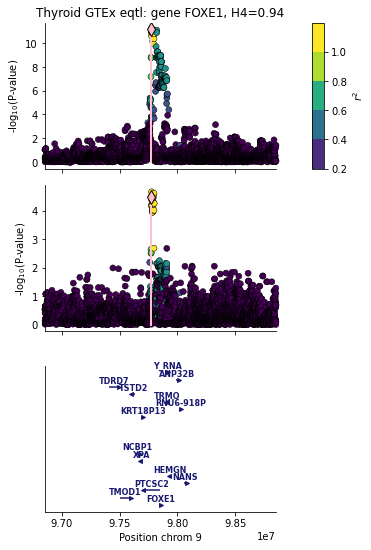

Running colocalizatio now for chr9_97772921_C_G_b38, gene FOXE1
Running colocalizatio now for chr9_97772921_C_G_b38, gene TRMO
Running colocalizatio now for chr9_97772921_C_G_b38, gene FOXE1
Running colocalizatio now for chr9_97772921_C_G_b38, gene TRMO
Running colocalizatio now for chr9_97772921_C_G_b38, gene TRMO
Running colocalizatio now for chr9_97772921_C_G_b38, gene TRMO
Running colocalizatio now for chr9_97772921_C_G_b38, gene TRMO
Running colocalizatio now for chr9_97772921_C_G_b38, gene NANS
Running colocalizatio now for chr10_17384475_A_C_b38, gene ST8SIA6-AS1
Running colocalizatio now for chr10_17384475_A_C_b38, gene ST8SIA6-AS1
Running colocalizatio now for chr10_17384475_A_C_b38, gene ST8SIA6-AS1
Running colocalizatio now for chr10_17384475_A_C_b38, gene ST8SIA6-AS1


<ipython-input-8-36d16047cc6c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtex_gene_sumstat['index'] = np.arange(len(gtex_gene_sumstat))
100%|██████████| 10290/10290 [00:19<00:00, 522.15it/s]


Running colocalizatio now for chr10_17384475_A_C_b38, gene ST8SIA6


<ipython-input-10-ef9da089501f>:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


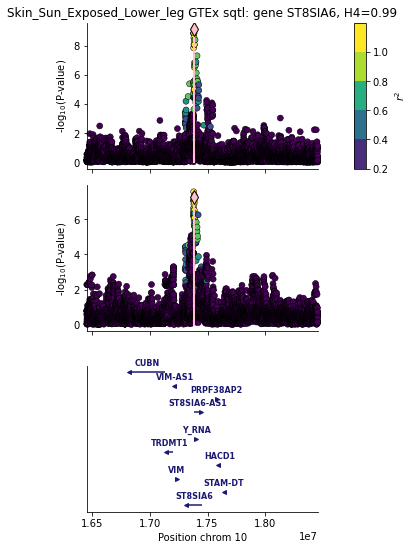

Running colocalizatio now for chr1_78663229_G_A_b38, gene IFI44


<ipython-input-10-ef9da089501f>:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


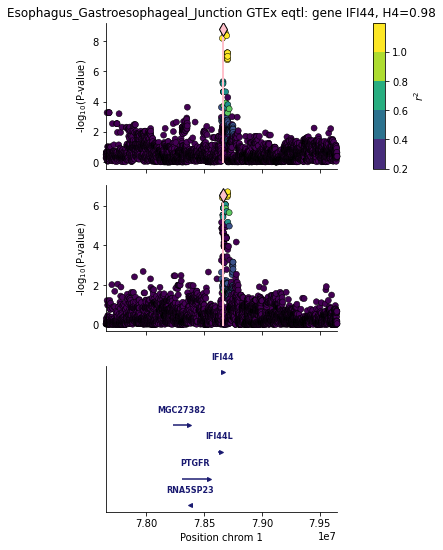

Running colocalizatio now for chr1_78663229_G_A_b38, gene IFI44
Running colocalizatio now for chr1_78663229_G_A_b38, gene IFI44


<ipython-input-10-ef9da089501f>:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


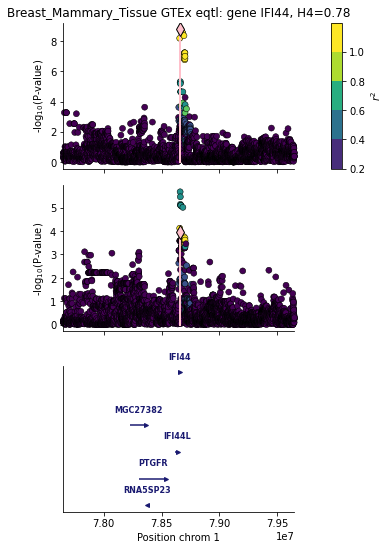

Running colocalizatio now for chr1_78663229_G_A_b38, gene IFI44L
Running colocalizatio now for chr1_78663229_G_A_b38, gene IFI44


In [13]:
all_tissue_hits_from_gwas = [
    ['Thyroid', '2', 'chr9_97772921_C_G_b38', 'blue'],
    ['Adipose_Subcutaneous', '1', 'chr10_17384475_A_C_b38', 'cyan'],
    ['Esophagus_Mucosa', '7', 'chr1_78663229_G_A_b38', 'green'],
    # ['Skin_Sun_Exposed_Lower_leg', '2', 'chr5_174255970_A_G_b38', 'brown'], 
]

tissue_for_eqtl_for_snp = {
    'chr9_97772921_C_G_b38': [('Thyroid', 'FOXE1', 'eqtl'),
                              ('Testis', 'FOXE1', 'eqtl'),
                              ('Testis', 'TRMO', 'eqtl'),
                              ('Esophagus_Mucosa', 'FOXE1', 'eqtl'),
                              ('Esophagus_Mucosa', 'TRMO', 'eqtl'),
                              ('Brain_Hypothalamus', 'TRMO', 'eqtl'),
                              ('Brain_Frontal_Cortex_BA9', 'TRMO', 'eqtl'),
                              ('Muscle_Skeletal', 'TRMO', 'eqtl'),
                              ('Cells_Cultured_fibroblasts', 'NANS', 'eqtl')],
    'chr10_17384475_A_C_b38': [
        ('Prostate', 'ST8SIA6-AS1', 'eqtl'),
         ('Pituitary', 'ST8SIA6-AS1', 'eqtl'),
         ('Heart_Atrial_Appendage', 'ST8SIA6-AS1', 'eqtl'),
         ('Testis', 'ST8SIA6-AS1', 'eqtl'),
        ('Skin_Sun_Exposed_Lower_leg', 'ST8SIA6', 'sqtl'),
         ],
    'chr1_78663229_G_A_b38': [
        ('Esophagus_Gastroesophageal_Junction', 'IFI44', 'eqtl'),
        ('Nerve_Tibial', 'IFI44', 'eqtl'),
        ('Breast_Mammary_Tissue', 'IFI44', 'eqtl'),
        ('Cells_Cultured_fibroblasts', 'IFI44L', 'eqtl'),
        ('Skin_Sun_Exposed_Lower_leg', 'IFI44', 'eqtl'),
        
    ]
}


outdir = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/colocalization/coloc_eqtl_plots'
os.makedirs(outdir, exist_ok=True)
all_summary = []
for tissue, cluster_i, snp, color in all_tissue_hits_from_gwas:
    
    # Reading the summary stat from gtex eqtl GWAS
    
    path_sumstat = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage6/hgwas/retccl/gwas_stat_cluster_{tissue}/{tissue}_cluster_{cluster_i}_hgwas.csv'
    df_sumstat = pd.read_csv(path_sumstat)
    radious_kb = 400
    window_kb = 1000*0.8*radious_kb
    export_ld(snp, df_sumstat, window_kb)
    
    
    # loading the ld file
    out = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/LD'
    ld_file = join(out, snp)
    dfld = pd.read_csv(f'{ld_file}.ld', sep=r"\s+")[['SNP_B', 'R2']]
    dfld.columns = ['snp', 'R2']
    
    _ = dfld['snp'].str.split('_').str
    chrom = _.get(0).str.split('chr').str[1]
    pos = _.get(1)
    unique_id = chrom + ':' + pos
    dfld['unique_id'] = unique_id

    for tissue_, gene, type_ in tissue_for_eqtl_for_snp[snp]:
        # for gene in gene_for_eqtl_for_snp[snp]:
        egene = get_egenes(tissue, version = 'v10')

        chrom, pos, _, _, _ = snp.split('_')
        chrom = int(chrom[3:])
        pos = int(pos)
        if type_ == 'eqtl':
            df_eqtl = pd.read_parquet(f'/lustre/groups/casale/datasets/gtex/eqtl_gwas/GTEx_Analysis_v10_QTLs_GTEx_Analysis_v10_eQTL_all_associations_{tissue_}.v10.allpairs.chr{chrom}.parquet')
        elif type_ == 'sqtl':
            df_eqtl = pd.read_parquet(f'/lustre/groups/casale/datasets/gtex/eqtl_gwas/GTEx_Analysis_v10_QTLs-GTEx_Analysis_v10_sQTL_all_associations-{tissue_}.v10.cis_sqtl.allpairs.chr10.parquet')
            df_eqtl['gene_id'] = df_eqtl['phenotype_id'].str.split(':').str.get(-1)

        gene_annot = '/lustre/groups/casale/datasets/annots/gencode.v41.annotation.autosomal.genes.tsv'


        # load all the necessary
        dfgene = pd.read_csv(gene_annot, sep='\t')

        # filter dfgene based on distance
        Ichrom = dfgene['chrom']==chrom
        gdist1 = abs(dfgene['start'].values - pos)
        gdist2 = abs(dfgene['end'].values - pos)
        dfgene['dist'] = np.minimum(gdist2, gdist2)
        dfgene = dfgene.loc[np.logical_and(dfgene['dist']<1000*0.8*radious_kb, Ichrom)]   

        temp = egene[egene['gene_name'].isin(dfgene['gene_name'].unique())]
        gene_name_to_id = dict(zip(temp['gene_name'], temp['gene_id']))


        key = gene
        gene_id = gene_name_to_id[key]
        gtex_gene_sumstat = df_eqtl[df_eqtl['gene_id']==gene_id]

        df_sumstat_temp = df_sumstat[df_sumstat['snp'].isin(gtex_gene_sumstat['variant_id'])]
        if type_ == 'sqtl':
            gtex_gene_sumstat = filter_sumstat(gtex_gene_sumstat)
        # Here I am merging the gtex_gene_sumstat and sumstat from image embedding
        idx1, idx2 = merge_dfs(df_sumstat_temp, gtex_gene_sumstat, key1='snp', key2='variant_id', left_index=False, right_index=False)

        df_sumstat_temp = df_sumstat_temp.iloc[idx1]
        gtex_gene_sumstat = gtex_gene_sumstat.iloc[idx2]



        # lead snp, chrom, pos

        chrom = int(snp.split('_')[0].split('chr')[1])
        pos = int(snp.split('_')[1])

        topsnp = df_sumstat_temp[df_sumstat_temp['snp']==snp]
        gtex_gene_sumstat['pos'] = gtex_gene_sumstat['variant_id'].str.split('_').str[1].astype(int)

        pvals = df_sumstat_temp['p_value'].values
        n = 750
        df_sumstat_temp['logBF'] = logbf_bic_from_p(pvals, n)
        W =0.04
        gtex_gene_sumstat['logBF'] = wakefield_logBF(gtex_gene_sumstat['slope'], gtex_gene_sumstat['slope_se'], W)


        _  = gtex_gene_sumstat['variant_id'].str.split('_')
        gtex_gene_sumstat.index = _.str.get(0).str[3:] +':'+ _.str.get(1)

        df_sumstat_temp.index = df_sumstat_temp['chrom'].astype(str) + ':' + df_sumstat_temp['pos'].astype('str')

        df_coloc = pd.DataFrame(columns=['snp', 'logBF_1', 'logBF_2'])
        df_coloc['logBF_1'] = df_sumstat_temp['logBF']
        df_coloc['p_value_1'] = df_sumstat_temp['p_value']
        df_coloc['logBF_2'] = gtex_gene_sumstat['logBF']
        df_coloc['p_value_2'] = gtex_gene_sumstat['pval_nominal']
        df_coloc['snp'] = df_sumstat_temp.index
   
        # adding LD value
        df_coloc['R2'] = (df_coloc.index).map(dict(zip(dfld['unique_id'], dfld['R2'])))

        df_coloc['pos'] = df_coloc['snp'].str.split(':').str.get(1).astype('int')
        outfile = join(outdir, f'{snp}_{tissue_}_{gene}.csv')
        df_coloc.to_csv(outfile, index=True)


        print(f"Running colocalizatio now for {snp}, gene {gene}")
        infile = outfile
        key = gene
        df_summary = run_coloc(snp, tissue_, key, infile)
        h4 = df_summary['PP.H4.abf'].values[0]


        snp_ = str(chrom) + ':' + str(pos)
        topsnp = df_coloc[df_coloc['snp'] == snp_]

        outfile = join(outdir,'plots', f'{snp}_for_{tissue}_eqtl_for_{tissue_}_for_{gene}_BF.PNG')
        os.makedirs(dirname(outfile), exist_ok=True)

        df_summary['tissue'] = tissue_
        df_summary['snp'] = snp
        df_summary['trait'] = type_

        all_summary.append(df_summary)

        bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
        df_coloc['R2_ordinal'] = pd.cut(df_coloc['R2'], bins, right=False, labels=False)
        df_coloc['R2_ordinal'] = df_coloc['R2_ordinal'].fillna(4.)
     
        if h4>0.75:
            plot_coloc_bayes_factor(df_coloc, dfgene, topsnp, tissue_, cluster_i, chrom, key, 
                        h4, outfile, type_
                       )

<ipython-input-55-4332cee799ec>:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_finngen = pd.read_csv("/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/colocalization/sumstats/summary_stats_release_finngen_R12_M13_ARTHROSIS_OTH.gz", sep="\t", compression="gzip")


 Now running for Skin_Sun_Exposed_Lower_leg, 2, chr5_174255970_A_G_b38


<ipython-input-55-4332cee799ec>:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset1['unique_id'] = dataset1['chrom'].astype('str') + ':' + dataset1['pos'].astype('str')
<ipython-input-55-4332cee799ec>:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset2['unique_id'] = dataset2['#chrom'].astype('str') + ":" + dataset2['pos'].astype('str')
<ipython-input-55-4332cee799ec>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

Running colocalizatio now for chr5_174255970_A_G_b38, gene IFI44


<ipython-input-43-ef9da089501f>:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


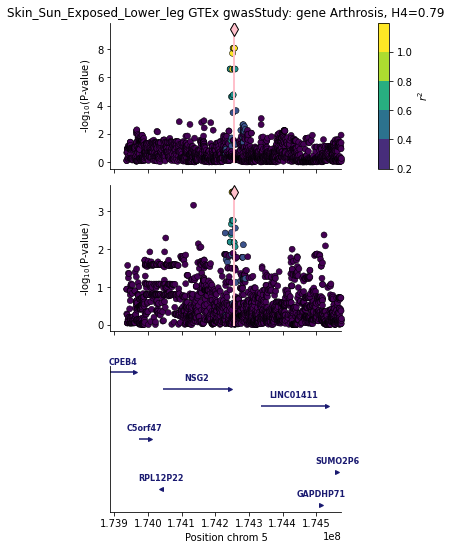

In [55]:
outdir = '/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/colocalization/coloc_eqtl_plots'
all_coloc_result = []
df_finngen = pd.read_csv("/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/colocalization/sumstats/summary_stats_release_finngen_R12_M13_ARTHROSIS_OTH.gz", sep="\t", compression="gzip")
tissue, cluster_i, snp, color = ['Skin_Sun_Exposed_Lower_leg', '2', 'chr5_174255970_A_G_b38', 'brown']
# Reading the summary stat from gtex eqtl GWAS


def export_ld(snp, df_sumstat, radious_kb):
    bfile = '/lustre/groups/casale/datasets/gtex/wgs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF02'
    plink = '/lustre/groups/casale/code/users/paolo.casale/software/plink-1.9/plink'
    out = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/LD'
    os.makedirs(out, exist_ok=True)
    # Extracting LD
    ld_file = join(out, snp)
    if not os.path.exists(ld_file):
        cmd = f"{plink} --bfile {bfile} --r2 --ld-snp {snp} --ld-window {len(df_sumstat)} --ld-window-kb {radious_kb} --ld-window-r2 0 --out {ld_file}"
        os.system(cmd)



path_sumstat = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage6/hgwas/retccl/gwas_stat_cluster_{tissue}/{tissue}_cluster_{cluster_i}_hgwas.csv'
df_sumstat = pd.read_csv(path_sumstat)


# # loading the ld file
out = f'/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/supplementary/review/LD'
ld_file = join(out, snp)
if os.path.exists(f'{ld_file}.ld'):
    dfld = pd.read_csv(f'{ld_file}.ld', sep=r"\s+")[['SNP_B', 'R2']]
else:
    export_ld(snp, df_sumstat, radious_kb)
    dfld = pd.read_csv(f'{ld_file}.ld', sep=r"\s+")[['SNP_B', 'R2']]
dfld.columns = ['snp', 'R2']

_ = dfld['snp'].str.split('_').str
chrom = _.get(0).str.split('chr').str[1]
pos = _.get(1)
unique_id = chrom + ':' + pos
dfld['unique_id'] = unique_id



# loading gene annotation
gene_annot = '/lustre/groups/casale/datasets/annots/gencode.v41.annotation.autosomal.genes.tsv'
chrom, pos, _, _, _ = snp.split('_')
pos = int(pos)
chrom = int(chrom[3:])

# load all the necessary
dfgene = pd.read_csv(gene_annot, sep='\t')

# filter dfgene based on distance
Ichrom = dfgene['chrom']==chrom
gdist1 = abs(dfgene['start'].values - pos)
gdist2 = abs(dfgene['end'].values - pos)
dfgene['dist'] = np.minimum(gdist2, gdist2)
dfgene = dfgene.loc[np.logical_and(dfgene['dist']<1000*0.8*radious_kb, Ichrom)]   


chrom, pos, _, _, _ = snp.split('_')
chrom = int(chrom[3:])
pos = int(pos)

radious_kb = 400
window = 1000*0.8*radious_kb
idx_1 = (df_sumstat['chrom'] == chrom).values
idx_2 = np.logical_and(pos - window < df_sumstat['pos'], df_sumstat['pos'] < pos + window)
dataset1 = df_sumstat[np.logical_and(idx_1, idx_2)]

print(f" Now running for {tissue}, {cluster_i}, {snp}")




logical_temp = (df_finngen['#chrom'] == chrom).values
radious_kb = 400
window = 1000*0.8*radious_kb
logical_temp_ = np.logical_and(df_finngen['pos'] > pos - window, df_finngen['pos']  < pos + window).values
idx_ = np.where(np.logical_and(logical_temp_, logical_temp))
dataset2 = df_finngen.iloc[idx_]


dataset1['unique_id'] = dataset1['chrom'].astype('str') + ':' + dataset1['pos'].astype('str')
dataset2['unique_id'] = dataset2['#chrom'].astype('str') + ":" + dataset2['pos'].astype('str')

idx1, idx2 = df_match([dataset1, dataset2], keys=['unique_id', 'unique_id'])

dataset1 = dataset1.iloc[idx1]
dataset2 = dataset2.iloc[idx2]

# extracting bayes factor
# dataset1['logBF'] = dataset1['llr'] - 0.5*np.log10(len(dfX))

pvals = dataset1['p_value'].values
n = 750
dataset1['logBF'] = logbf_bic_from_p(pvals, n)

W = 0.04
dataset2['logBF'] = wakefield_logBF(dataset2['beta'], dataset2['sebeta'], W)

df_coloc = pd.DataFrame(columns=['snp', 'logBF_1', 'logBF_2'])
dataset2.index = dataset2['unique_id']
dataset1.index = dataset1['unique_id']



df_coloc['logBF_1'] = dataset1['logBF']
df_coloc['logBF_2'] = dataset2['logBF']

df_coloc['p_value_1'] = dataset1['p_value']
df_coloc['p_value_2'] = dataset2['pval']

df_coloc['snp'] = dataset1.index

key = 'Arthrosis'
outfile = join(outdir, f'{snp}_{tissue_}_{key}.csv')
df_coloc.to_csv(outfile, index=True)


print(f"Running colocalizatio now for {snp}, gene {gene}")
infile = outfile
df_summary = run_coloc(snp, tissue_, key, infile)


df_summary = run_coloc(snp, tissue_, key, infile)
df_coloc['pos'] = df_coloc['snp'].str.split(':').str.get(1).astype('int')
topsnp = df_coloc[df_coloc['snp'] == str(chrom) + ':' + str(pos)]
type_ = 'gwasStudy'
h4 = df_summary['PP.H4.abf'].values[0]

 # adding LD value
df_coloc['R2'] = (df_coloc.index).map(dict(zip(dfld['unique_id'], dfld['R2'])))
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
df_coloc['R2_ordinal'] = pd.cut(df_coloc['R2'], bins, right=False, labels=False)
df_coloc['R2_ordinal'] = df_coloc['R2_ordinal'].fillna(4.)
outfile = join(outdir,'plots', f'{snp}_for_{tissue}_eqtl_for_{tissue_}_for_{key}_BF.PNG')
plot_coloc_bayes_factor(df_coloc, dfgene, topsnp, tissue_, cluster_i, chrom, key, 
                        h4, outfile, type_
                       )